# DENTEX Results Plots

This notebook creates representative plots from the saved result artefacts. The plots are intended to support the concise findings in `insights.md`.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_ROOT = PROJECT_ROOT / "results"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 5), "axes.titleweight": "bold"})

FIGURE_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
baseline = pd.read_csv(
    RESULTS_ROOT / "dual_detector_baseline_ablation" / "predictions" / "experiment_comparison.csv"
)
assignment = pd.read_csv(
    RESULTS_ROOT / "dual_detector_baseline_ablation" / "predictions" / "assignment_ablation.csv"
)
regularisation = pd.read_csv(
    RESULTS_ROOT / "dual_detector_regularisation_ablation" / "predictions" / "regularisation_comparison.csv"
)
quadrant = pd.read_csv(
    RESULTS_ROOT / "quadrant_detector_ablation" / "predictions" / "model_c_pipeline_comparison.csv"
)
ap75_sweep = pd.read_csv(
    RESULTS_ROOT / "best_checkpoint_test_inference" / "predictions" / "ap75_threshold_sweep.csv"
)
clean_review = pd.read_csv(
    RESULTS_ROOT / "best_checkpoint_test_inference" / "predictions" / "clean_review_validation_comparison.csv"
)

with open(
    RESULTS_ROOT / "task_specific_detector_fusion" / "predictions" / "final_metrics_validation_official_style.json",
    "r",
    encoding="utf-8",
) as file:
    final_validation = json.load(file)

with open(
    RESULTS_ROOT / "task_specific_detector_fusion" / "predictions" / "final_metrics_released_test_official_style.json",
    "r",
    encoding="utf-8",
) as file:
    final_test = json.load(file)

## Model Architecture

The final system uses three task-specific detectors. Pathology boxes carry the disease label, tooth boxes provide enumeration, and quadrant boxes provide the quadrant label. A nearest-assignment fusion step combines the three outputs into the challenge prediction format.

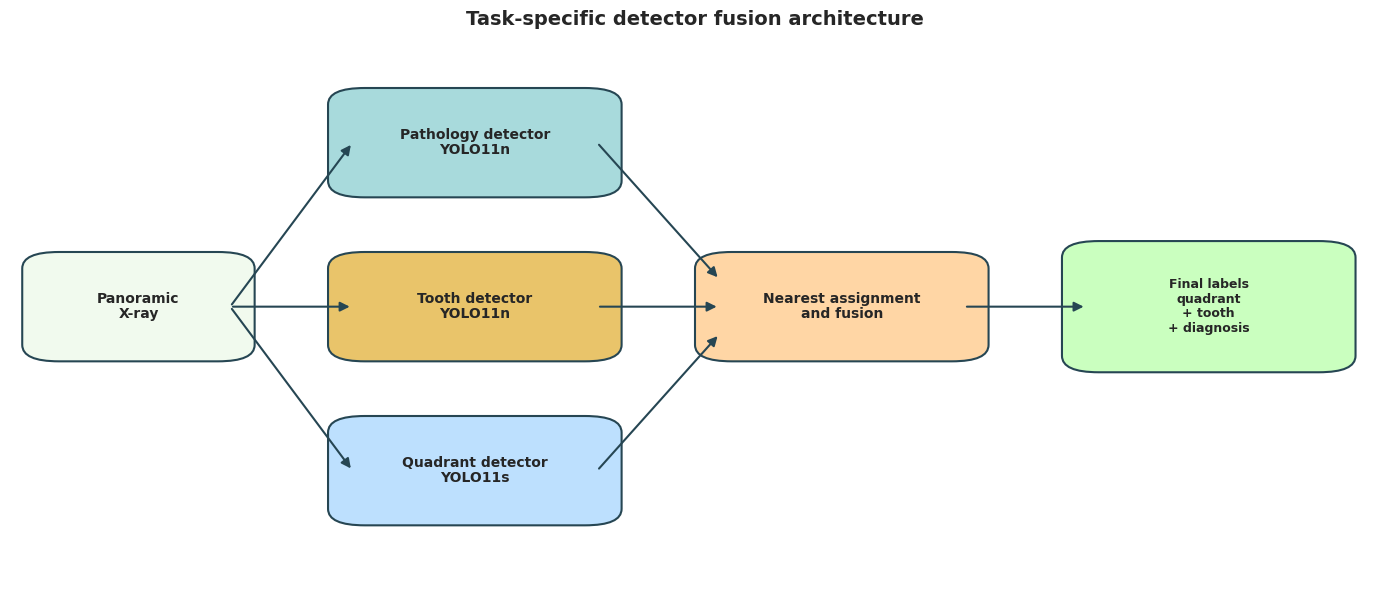

In [3]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_box(ax, xy, width, height, text, colour, fontsize=10):
    box = FancyBboxPatch(
        xy,
        width,
        height,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=1.5,
        edgecolor="#264653",
        facecolor=colour,
    )
    ax.add_patch(box)
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        weight="bold",
        linespacing=1.15,
    )

def add_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.5,
        color="#264653",
    )
    ax.add_patch(arrow)

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 1.12)
ax.set_ylim(0, 1)
ax.axis("off")

add_box(ax, (0.03, 0.42), 0.15, 0.16, "Panoramic\nX-ray", "#f1faee")
add_box(ax, (0.28, 0.72), 0.20, 0.16, "Pathology detector\nYOLO11n", "#a8dadc")
add_box(ax, (0.28, 0.42), 0.20, 0.16, "Tooth detector\nYOLO11n", "#e9c46a")
add_box(ax, (0.28, 0.12), 0.20, 0.16, "Quadrant detector\nYOLO11s", "#bde0fe")
add_box(ax, (0.58, 0.42), 0.20, 0.16, "Nearest assignment\nand fusion", "#ffd6a5")
add_box(ax, (0.88, 0.40), 0.20, 0.20, "Final labels\nquadrant\n+ tooth\n+ diagnosis", "#caffbf", fontsize=9)

for y in [0.80, 0.50, 0.20]:
    add_arrow(ax, (0.18, 0.50), (0.28, y))
add_arrow(ax, (0.48, 0.80), (0.58, 0.55))
add_arrow(ax, (0.48, 0.50), (0.58, 0.50))
add_arrow(ax, (0.48, 0.20), (0.58, 0.45))
add_arrow(ax, (0.78, 0.50), (0.88, 0.50))

ax.set_title("Task-specific detector fusion architecture", fontsize=14, weight="bold")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "architecture_task_specific_detector_fusion.png", dpi=200, bbox_inches="tight")

## Model Variations Tested

The variations tried were:

- **Model capacity:** YOLO11n baseline versus larger YOLO11s pathology and quadrant models.
- **Input resolution:** 1024 px baseline versus 1280 px.
- **Augmentation strength:** standard augmentation versus lower augmentation.
- **Training regularisation:** lower learning rate, higher weight decay, and shorter patience.
- **Assignment strategy:** nearest, IoU-first, and Hungarian matching between pathology and teeth.
- **Task decomposition:** layout-derived quadrant labels versus a dedicated quadrant detector.
- **Operating point:** AP-optimised thresholds versus clean-review post-processing.

The table below lists the representative variants plotted in the architecture summary.

In [4]:
variation_rows = [
    {
        "stage": "Baseline",
        "pathology": "YOLO11n",
        "tooth": "YOLO11n",
        "quadrant": "Layout inference",
        "variation": "1024 px, standard aug",
        "aggregate_AP50": baseline.loc[baseline["experiment"].eq("baseline_yolo11n_1024"), "aggregate_AP50"].iloc[0],
    },
    {
        "stage": "Larger pathology",
        "pathology": "YOLO11s",
        "tooth": "YOLO11n",
        "quadrant": "Layout inference",
        "variation": "More pathology capacity",
        "aggregate_AP50": baseline.loc[baseline["experiment"].eq("larger_pathology_yolo11s"), "aggregate_AP50"].iloc[0],
    },
    {
        "stage": "Higher resolution",
        "pathology": "YOLO11n",
        "tooth": "YOLO11n",
        "quadrant": "Layout inference",
        "variation": "1280 px",
        "aggregate_AP50": baseline.loc[baseline["experiment"].eq("higher_resolution_1280"), "aggregate_AP50"].iloc[0],
    },
    {
        "stage": "Lower learning rate",
        "pathology": "YOLO11n",
        "tooth": "YOLO11n",
        "quadrant": "Layout inference",
        "variation": "lr0 = 0.003",
        "aggregate_AP50": regularisation.loc[regularisation["experiment"].eq("lower_lr"), "aggregate_AP50"].iloc[0],
    },
    {
        "stage": "Dedicated quadrant",
        "pathology": "YOLO11n",
        "tooth": "YOLO11n",
        "quadrant": "YOLO11s",
        "variation": "Separate quadrant detector",
        "aggregate_AP50": quadrant.iloc[0]["aggregate_AP50"],
    },
    {
        "stage": "Clean review",
        "pathology": "YOLO11n",
        "tooth": "YOLO11n",
        "quadrant": "YOLO11s",
        "variation": "Higher pathology threshold + NMS",
        "aggregate_AP50": clean_review.loc[clean_review["mode"].eq("clean_review"), "aggregate_AP50"].iloc[0],
    },
]
variations = pd.DataFrame(variation_rows)
display(variations)

,stage,pathology,tooth,quadrant,variation,aggregate_AP50
0,Baseline,YOLO11n,YOLO11n,Layout inference,"1024 px, standard aug",0.234011
1,Larger pathology,YOLO11s,YOLO11n,Layout inference,More pathology capacity,0.224065
2,Higher resolution,YOLO11n,YOLO11n,Layout inference,1280 px,0.181963
3,Lower learning rate,YOLO11n,YOLO11n,Layout inference,lr0 = 0.003,0.271935
4,Dedicated quadrant,YOLO11n,YOLO11n,YOLO11s,Separate quadrant detector,0.460433
5,Clean review,YOLO11n,YOLO11n,YOLO11s,Higher pathology threshold + NMS,0.396510


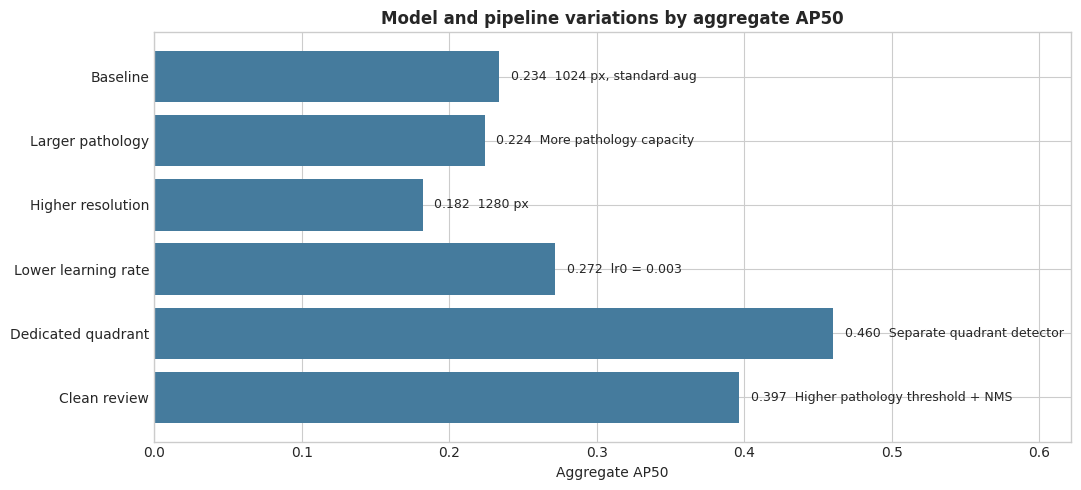

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(variations["stage"], variations["aggregate_AP50"], color="#457b9d")
ax.set_title("Model and pipeline variations by aggregate AP50")
ax.set_xlabel("Aggregate AP50")
ax.set_ylabel("")
ax.invert_yaxis()
for bar, label in zip(bars, variations["variation"]):
    width = bar.get_width()
    ax.text(width + 0.008, bar.get_y() + bar.get_height() / 2, f"{width:.3f}  {label}", va="center", fontsize=9)
ax.set_xlim(0, max(variations["aggregate_AP50"]) * 1.35)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "model_variations_ap50.png", dpi=200, bbox_inches="tight")

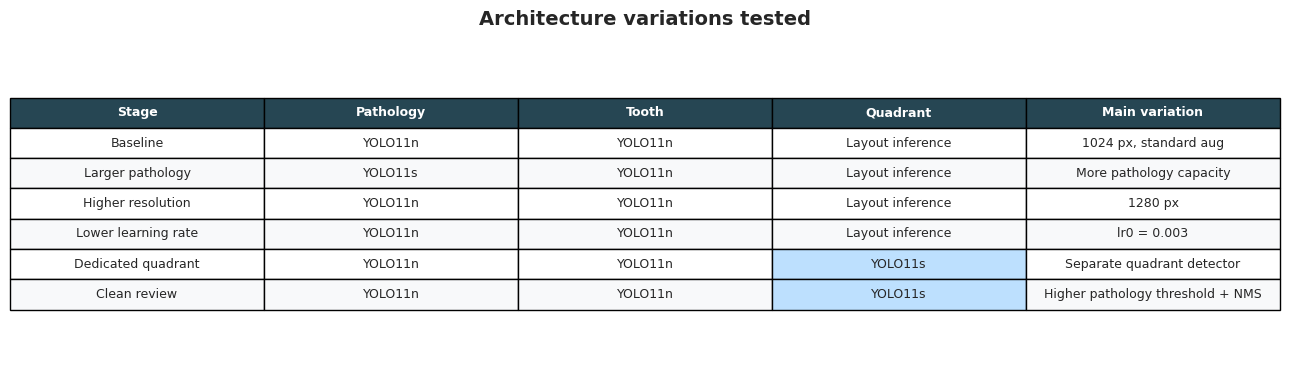

In [6]:
architecture_matrix = variations[["stage", "pathology", "tooth", "quadrant", "variation"]].copy()
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.axis("off")
table = ax.table(
    cellText=architecture_matrix.values,
    colLabels=["Stage", "Pathology", "Tooth", "Quadrant", "Main variation"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.7)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#264653")
        cell.set_text_props(color="white", weight="bold")
    elif col == 3 and architecture_matrix.iloc[row - 1, col] == "YOLO11s":
        cell.set_facecolor("#bde0fe")
    elif row % 2 == 0:
        cell.set_facecolor("#f8f9fa")
ax.set_title("Architecture variations tested", fontsize=14, weight="bold", pad=16)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "architecture_variations_matrix.png", dpi=200, bbox_inches="tight")

## Model A + B Loss Curves

Model A and Model B training curves are plotted from the best two-detector baseline run.

In [ ]:
model_ab_loss_sources = {
    "Model A pathology": RESULTS_ROOT
    / "dual_detector_baseline_ablation"
    / "training_curves"
    / "baseline_with_tta_pathology"
    / "results.csv",
    "Model B tooth": RESULTS_ROOT
    / "dual_detector_baseline_ablation"
    / "training_curves"
    / "baseline_with_tta_tooth"
    / "results.csv",
}

loss_rows = []
for model_name, loss_path in model_ab_loss_sources.items():
    curve = pd.read_csv(loss_path)
    for split_name, prefix in [("Training", "train"), ("Validation", "val")]:
        total_loss = curve[
            [f"{prefix}/box_loss", f"{prefix}/cls_loss", f"{prefix}/dfl_loss"]
        ].sum(axis=1)
        loss_rows.append(
            pd.DataFrame(
                {
                    "epoch": curve["epoch"],
                    "model": model_name,
                    "split": split_name,
                    "total_loss": total_loss,
                }
            )
        )

model_ab_losses = pd.concat(loss_rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
loss_colours = {"Training": "#2a9d8f", "Validation": "#e76f51"}
loss_styles = {"Training": "-", "Validation": "--"}

for ax, (model_name, model_losses) in zip(
    axes, model_ab_losses.groupby("model", sort=False)
):
    for split_name, split_losses in model_losses.groupby("split", sort=False):
        ax.plot(
            split_losses["epoch"],
            split_losses["total_loss"],
            label=split_name,
            color=loss_colours[split_name],
            linestyle=loss_styles[split_name],
            linewidth=2,
        )
    ax.set_title(model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Total loss (box + class + DFL)")
    ax.legend(frameon=False)

fig.suptitle("Model A + B training and validation loss", fontsize=14, weight="bold")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "model_ab_training_validation_loss.png", dpi=200, bbox_inches="tight")

## Headline Progression

The main modelling improvement was moving from a two-detector baseline to task-specific detector fusion with a dedicated quadrant detector.

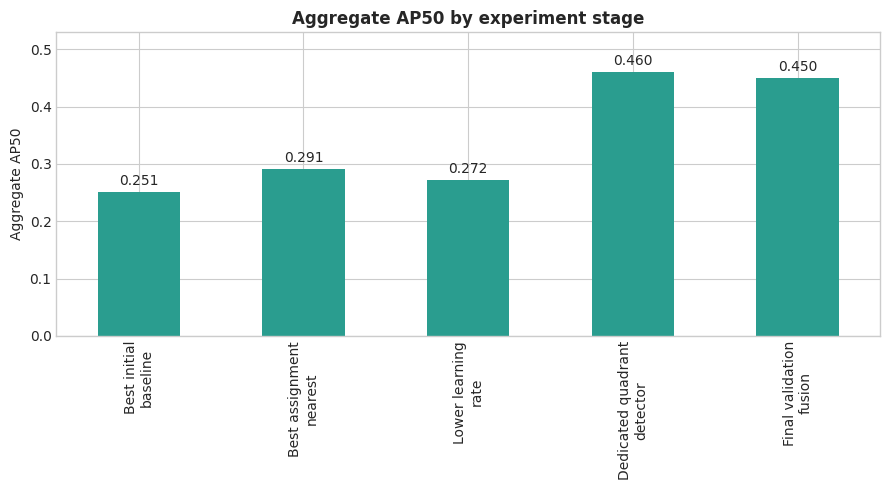

In [7]:
headline = pd.DataFrame(
    [
        {
            "stage": "Best initial\nbaseline",
            "aggregate_AP50": baseline.loc[baseline["experiment"].eq("baseline_with_tta"), "aggregate_AP50"].iloc[0],
        },
        {
            "stage": "Best assignment\nnearest",
            "aggregate_AP50": assignment.loc[assignment["assignment_mode"].eq("nearest"), "aggregate_AP50"].iloc[0],
        },
        {
            "stage": "Lower learning\nrate",
            "aggregate_AP50": regularisation.loc[regularisation["experiment"].eq("lower_lr"), "aggregate_AP50"].iloc[0],
        },
        {
            "stage": "Dedicated quadrant\ndetector",
            "aggregate_AP50": quadrant.iloc[0]["aggregate_AP50"],
        },
        {
            "stage": "Final validation\nfusion",
            "aggregate_AP50": final_validation["Aggregates"]["AP50"],
        },
    ]
)

ax = headline.plot.bar(x="stage", y="aggregate_AP50", legend=False, color="#2a9d8f")
ax.set_title("Aggregate AP50 by experiment stage")
ax.set_xlabel("")
ax.set_ylabel("Aggregate AP50")
ax.set_ylim(0, max(headline["aggregate_AP50"]) * 1.15)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.tight_layout()

## Quadrant Bottleneck

The baseline failed on quadrant AP50 because quadrant was inferred indirectly. The dedicated quadrant detector fixed the main bottleneck.

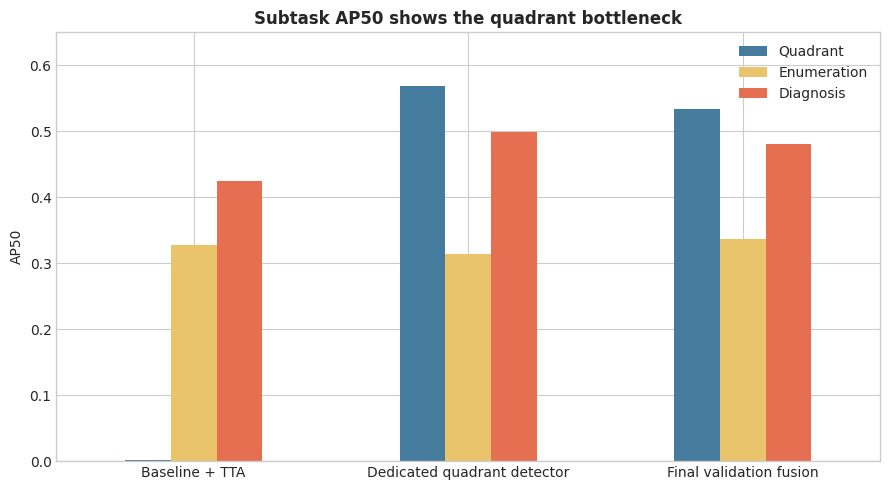

In [8]:
subtask_rows = [
    {
        "stage": "Baseline + TTA",
        "Quadrant": baseline.loc[baseline["experiment"].eq("baseline_with_tta"), "quadrant_AP50"].iloc[0],
        "Enumeration": baseline.loc[baseline["experiment"].eq("baseline_with_tta"), "enumeration_AP50"].iloc[0],
        "Diagnosis": baseline.loc[baseline["experiment"].eq("baseline_with_tta"), "diagnosis_AP50"].iloc[0],
    },
    {
        "stage": "Dedicated quadrant detector",
        "Quadrant": quadrant.iloc[0]["quadrant_AP50"],
        "Enumeration": quadrant.iloc[0]["enumeration_AP50"],
        "Diagnosis": quadrant.iloc[0]["diagnosis_AP50"],
    },
    {
        "stage": "Final validation fusion",
        "Quadrant": final_validation["Quadrant"]["AP50"],
        "Enumeration": final_validation["Enumeration"]["AP50"],
        "Diagnosis": final_validation["Diagnosis"]["AP50"],
    },
]
subtask = pd.DataFrame(subtask_rows).set_index("stage")

ax = subtask.plot.bar(color=["#457b9d", "#e9c46a", "#e76f51"])
ax.set_title("Subtask AP50 shows the quadrant bottleneck")
ax.set_xlabel("")
ax.set_ylabel("AP50")
ax.set_ylim(0, 0.65)
plt.xticks(rotation=0)
plt.tight_layout()

## Threshold Behaviour

The AP75 sweep shows that stricter pathology thresholds reduce predictions, but AP75 still prefers the recall-heavy low threshold.

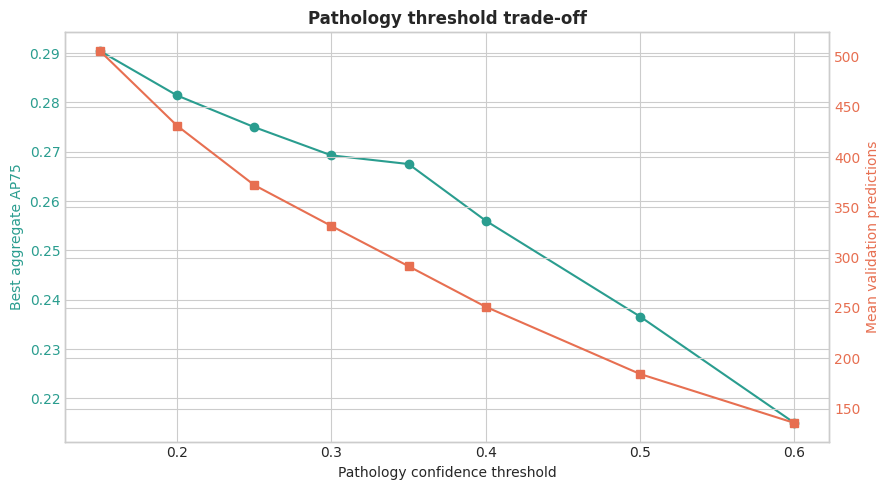

In [9]:
threshold_view = (
    ap75_sweep.groupby("pathology_conf", as_index=False)
    .agg(
        aggregate_AP75=("aggregate_AP75", "max"),
        predictions=("predictions", "mean"),
        diagnosis_AP75=("diagnosis_AP75", "max"),
    )
    .sort_values("pathology_conf")
)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(threshold_view["pathology_conf"], threshold_view["aggregate_AP75"], marker="o", color="#2a9d8f")
ax2.plot(threshold_view["pathology_conf"], threshold_view["predictions"], marker="s", color="#e76f51")
ax1.set_title("Pathology threshold trade-off")
ax1.set_xlabel("Pathology confidence threshold")
ax1.set_ylabel("Best aggregate AP75", color="#2a9d8f")
ax2.set_ylabel("Mean validation predictions", color="#e76f51")
ax1.tick_params(axis="y", labelcolor="#2a9d8f")
ax2.tick_params(axis="y", labelcolor="#e76f51")
plt.tight_layout()

## Clean Review Mode

Clean review mode is useful for qualitative inspection, but it trades away recall and AP.

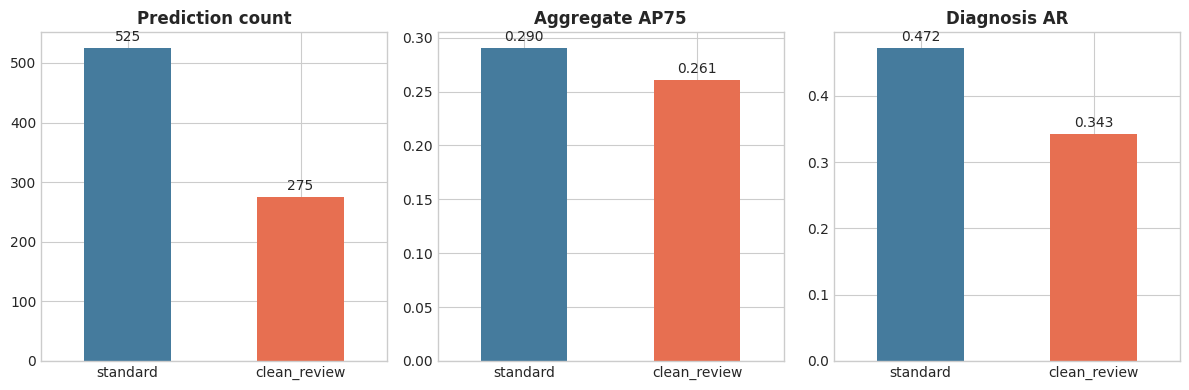

In [10]:
plot_df = clean_review.set_index("mode")[[
    "predictions",
    "aggregate_AP75",
    "diagnosis_AR",
]]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, column, title in zip(
    axes,
    ["predictions", "aggregate_AP75", "diagnosis_AR"],
    ["Prediction count", "Aggregate AP75", "Diagnosis AR"],
):
    plot_df[column].plot.bar(ax=ax, color=["#457b9d", "#e76f51"])
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    for container in ax.containers:
        fmt = "%.0f" if column == "predictions" else "%.3f"
        ax.bar_label(container, fmt=fmt, padding=3)
plt.tight_layout()

## Validation Versus Released Test

The final model generalises reasonably on quadrant and diagnosis after label-space filtering, but enumeration drops on released test.

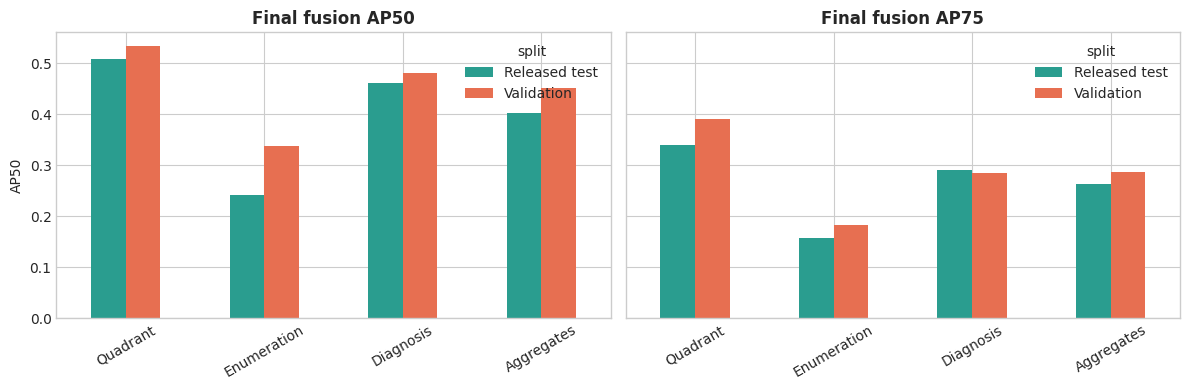

In [11]:
rows = []
for split_name, payload in [("Validation", final_validation), ("Released test", final_test)]:
    for task in ["Quadrant", "Enumeration", "Diagnosis", "Aggregates"]:
        rows.append({"split": split_name, "task": task, "AP50": payload[task]["AP50"], "AP75": payload[task]["AP75"]})
final_compare = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, metric in zip(axes, ["AP50", "AP75"]):
    pivot = final_compare.pivot(index="task", columns="split", values=metric).loc[
        ["Quadrant", "Enumeration", "Diagnosis", "Aggregates"]
    ]
    pivot.plot.bar(ax=ax, color=["#2a9d8f", "#e76f51"])
    ax.set_title(f"Final fusion {metric}")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()